# Optimal power flow over a day: one generated AC-OPF solver, re-solved every hour

An optimal power flow (OPF) dispatches generators at least cost, subject to the network's
physics, voltage limits and line ratings. System operators solve it again whenever the loads
change, which means every few minutes in real-time markets and hourly in day-ahead studies. The
network stays the same between solves, and only the loads change. That is the pattern a
generated solver is made for.

This notebook takes the WSCC 9-bus system (MATPOWER's `case9`, the data of
`examples/optimal_power_flow.py`) and makes the loads a **parameter** of the problem. It then solves
a 24-hour load profile twice. Once as the nonconvex AC-OPF, with IPOPT and exact sparse
derivatives. Once as its DC approximation, a QP for PIQP. Comparing the two shows what the
linearization gets wrong: the losses and the prices.

| Scaly feature | Where |
| --- | --- |
| `sc.gather`, `sc.segment_sum`, `sc.scatter` with the network as index tables | line flows and bus balances |
| `sc.opt.problem` with loads as parameters, warm-started IPOPT | 24 AC-OPF solves with one compiled solver |
| the same tables in a QP, `sc.opt.solver(..., sc.opt.PIQP(sparse=True))` | the DC-OPF |
| `sc.jacobian_sparsity` | the Jacobian's pattern is the network's |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import plotstyle
import scaly as sc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "opf_day_ahead"

## The network as tables

Buses, lines and generators are arrays of numbers. Every line has a from-bus and a to-bus, a
series impedance $r + jx$, a charging susceptance $b$ and a thermal rating. The code below never
loops over lines. It gathers voltages at the line ends and sums line flows into buses.

In [2]:
BASE_MVA = 100.0
N_BUS = 9
PD_NOM = np.array([0, 0, 0, 0, 90, 0, 100, 0, 125]) / BASE_MVA
QD_NOM = np.array([0, 0, 0, 0, 30, 0, 35, 0, 50]) / BASE_MVA
GEN_BUS = np.array([0, 1, 2])
P_MIN, P_MAX = np.array([10, 10, 10]) / BASE_MVA, np.array([250, 300, 270]) / BASE_MVA
Q_LIM = 300 / BASE_MVA
COST = np.array([[0.11, 5.0, 150.0], [0.085, 1.2, 600.0], [0.1225, 1.0, 335.0]])  # $/h with P in MW
LINES = np.array(
  [
    [0, 3, 0.0, 0.0576, 0.0, 250],
    [3, 4, 0.017, 0.092, 0.158, 250],
    [4, 5, 0.039, 0.17, 0.358, 150],
    [2, 5, 0.0, 0.0586, 0.0, 300],
    [5, 6, 0.0119, 0.1008, 0.209, 150],
    [6, 7, 0.0085, 0.072, 0.149, 250],
    [7, 1, 0.0, 0.0625, 0.0, 250],
    [7, 8, 0.032, 0.161, 0.306, 250],
    [8, 3, 0.01, 0.085, 0.176, 250],
  ]
)
FROM, TO = LINES[:, 0].astype(int), LINES[:, 1].astype(int)
Y_SERIES = 1.0 / (LINES[:, 2] + 1j * LINES[:, 3])
G_S, B_S, B_C, X_L = Y_SERIES.real, Y_SERIES.imag, LINES[:, 4], LINES[:, 3]
RATE = LINES[:, 5] / BASE_MVA
ENDS = np.r_[FROM, TO]


def cost_of(pg):
  mw = BASE_MVA * pg
  return (sc.const(COST[:, 0]) * mw * mw + sc.const(COST[:, 1]) * mw + sc.const(COST[:, 2])).sum()

## AC-OPF with the loads as parameters

The formulation is the script's: polar voltages, the $\pi$ line model, balances by `segment_sum`,
ratings on apparent power at both ends. The difference is the parameter tree
$(P_d, Q_d)$, which turns the compiled solver into a function of the loads.

In [3]:
def line_flows(theta, v):
  vf, vt = sc.gather(v, FROM), sc.gather(v, TO)
  dtheta = sc.gather(theta, FROM) - sc.gather(theta, TO)
  g, b, bc = sc.const(G_S), sc.const(B_S), sc.const(B_C)
  c, s = dtheta.cos(), dtheta.sin()
  p_ft = g * vf * vf - vf * vt * (g * c + b * s)
  q_ft = -(b + 0.5 * bc) * vf * vf - vf * vt * (g * s - b * c)
  p_tf = g * vt * vt - vf * vt * (g * c - b * s)
  q_tf = -(b + 0.5 * bc) * vt * vt - vf * vt * (-g * s - b * c)
  return p_ft, q_ft, p_tf, q_tf


@sc.opt.problem(vars=sc.G(sc.L("theta", N_BUS), sc.L("v", N_BUS), sc.L("pg", 3), sc.L("qg", 3)), params=sc.G(sc.L("pd", N_BUS), sc.L("qd", N_BUS)))
def ac_opf(variables, loads):
  theta, v, pg, qg = variables
  pd, qd = loads
  p_ft, q_ft, p_tf, q_tf = line_flows(theta, v)
  p_balance = sc.scatter(pg, GEN_BUS, N_BUS) - pd - sc.segment_sum(sc.concat([p_ft, p_tf]), ENDS, N_BUS)
  q_balance = sc.scatter(qg, GEN_BUS, N_BUS) - qd - sc.segment_sum(sc.concat([q_ft, q_tf]), ENDS, N_BUS)
  loading = sc.concat([p_ft * p_ft + q_ft * q_ft, p_tf * p_tf + q_tf * q_tf])
  return sc.opt.ProblemSpec(
    minimize=cost_of(pg),
    eq=(theta[0:1], p_balance, q_balance),
    ineq=(sc.opt.bounded(loading, hi=sc.const(np.r_[RATE, RATE] ** 2), name="ratings"),),
    lb=(sc.opt.NO_LB, sc.const(np.full(N_BUS, 0.9)), sc.const(P_MIN), sc.const(np.full(3, -Q_LIM))),
    ub=(sc.opt.NO_UB, sc.const(np.full(N_BUS, 1.1)), sc.const(P_MAX), sc.const(np.full(3, Q_LIM))),
  )


solve_ac = sc.opt.solver(ac_opf, sc.opt.IPOPT(options={"tol": 1e-10}), name="ac_opf_case9")


def run_ac(pd, qd, start):
  zeros = (np.zeros(N_BUS), np.zeros(N_BUS), np.zeros(3), np.zeros(3))
  x, _, lam_eq, lam_ineq, _ = solve_ac(start, zeros, np.zeros(ac_opf.n_eq), np.zeros(ac_opf.n_ineq), (pd, qd))
  stats = sc.opt.solver_stats(solve_ac)
  return x, {"cost": float(stats.obj), "iter": stats.iter, "status": stats.to_solver_status(), "lmp": -lam_eq[1 : 1 + N_BUS] / BASE_MVA}


flat = (np.zeros(N_BUS), np.ones(N_BUS), 0.5 * (P_MIN + P_MAX), np.zeros(3))
x_nom, info = run_ac(PD_NOM, QD_NOM, flat)
print(f"nominal loads: {info['status'].name} in {info['iter']} iterations, cost {info['cost']:.2f} $/h (MATPOWER's published optimum: 5296.69)")

nominal loads: OK in 13 iterations, cost 5296.69 $/h (MATPOWER's published optimum: 5296.69)


### The structure comes from the tables

The constraint Jacobian of the balances in the voltages has a nonzero at $(i, j)$ exactly when
buses $i$ and $j$ are the same or joined by a line. That is the network's admittance pattern,
found by Scaly from the gathers and segment sums.

Jacobian pattern equals bus adjacency: True


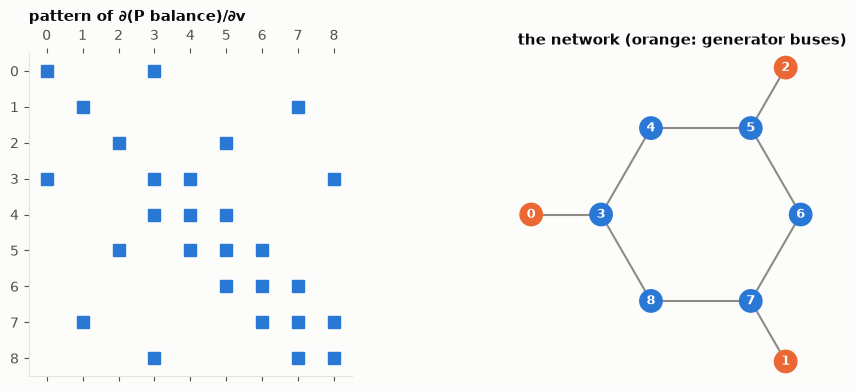

In [4]:
theta_s, v_s = sc.sym("theta", N_BUS), sc.sym("v", N_BUS)
p_ft, _, p_tf, _ = line_flows(theta_s, v_s)
balance = sc.segment_sum(sc.concat([p_ft, p_tf]), ENDS, N_BUS)
pattern = sc.jacobian_sparsity(balance, v_s).to_mask()
adjacency = np.eye(N_BUS, dtype=bool)
adjacency[FROM, TO] = adjacency[TO, FROM] = True
print("Jacobian pattern equals bus adjacency:", np.array_equal(pattern, adjacency))

ANGLE = {3: 180, 4: 120, 5: 60, 6: 0, 7: -60, 8: -120}  # the ring 3-4-5-6-7-8, generators outside it
POS = np.zeros((N_BUS, 2))
for bus, deg in ANGLE.items():
  POS[bus] = np.cos(np.radians(deg)), np.sin(np.radians(deg))
for gen, bus in zip(GEN_BUS, (3, 7, 5)):
  POS[gen] = 1.7 * POS[bus]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8))
ax1.spy(pattern, markersize=9, color=plotstyle.BLUE)
ax1.set_title("pattern of ∂(P balance)/∂v")
ax1.grid(False)
for f, t in zip(FROM, TO):
  ax2.plot(*POS[[f, t]].T, color=plotstyle.NEUTRAL, lw=1.5, zorder=0)
ax2.scatter(*POS.T, s=260, color=[plotstyle.ORANGE if i in GEN_BUS else plotstyle.BLUE for i in range(N_BUS)], zorder=1)
for i, p in enumerate(POS):
  ax2.text(*p, str(i), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax2.set_title("the network (orange: generator buses)")
ax2.set_aspect("equal")
ax2.axis("off")
plt.show()

## A day of loads

A day of hourly load profiles is built from a typical double-peaked shape. The three load buses
follow it with different mixes: residential at bus 4, commercial at bus 6 and industrial at bus 8.
Each hour's solve starts from the previous hour's solution. IPOPT always uses the primal warm start.

In [5]:
hours = np.arange(24)
residential = 0.62 + 0.18 * np.exp(-((hours - 8) ** 2) / 6) + 0.38 * np.exp(-((hours - 19.5) ** 2) / 5)
commercial = 0.55 + 0.5 / (1 + np.exp(-(hours - 8.5) * 1.5)) - 0.5 / (1 + np.exp(-(hours - 18) * 1.5))
industrial = 0.85 + 0.1 * np.sin(2 * np.pi * (hours - 6) / 24)
PROFILE = np.ones((24, N_BUS))
PROFILE[:, 4], PROFILE[:, 6], PROFILE[:, 8] = residential, commercial, industrial
PROFILE *= 1.08  # a heavier day than case9's nominal point

ac_day, start, elapsed = [], flat, []
for h in hours:
  tic = time.perf_counter()
  x, info = run_ac(PD_NOM * PROFILE[h], QD_NOM * PROFILE[h], start)
  elapsed.append(time.perf_counter() - tic)
  ac_day.append((x, info))
  start = x
print(
  f"24 AC-OPF solves, statuses {sorted(set(i['status'].name for _, i in ac_day))}: {np.mean([i['iter'] for _, i in ac_day]):.1f} iterations and {1e3 * np.median(elapsed):.2f} ms per solve (median)"
)

24 AC-OPF solves, statuses ['OK']: 11.9 iterations and 5.47 ms per solve (median)


## The DC approximation, as a QP

DC-OPF assumes flat voltages, small angle differences and lossless lines, so that
$P_{ft} = (\theta_f - \theta_t)/x$. The same tables give a QP with a convex quadratic cost. Scaly proves
it quadratic, and PIQP solves it with the pattern of the network baked in.

In [6]:
@sc.opt.problem(vars=sc.G(sc.L("theta", N_BUS), sc.L("pg", 3)), params=sc.L("pd", N_BUS))
def dc_opf(variables, pd):
  theta, pg = variables
  flow = (sc.gather(theta, FROM) - sc.gather(theta, TO)) / sc.const(X_L)
  balance = sc.scatter(pg, GEN_BUS, N_BUS) - pd - sc.segment_sum(sc.concat([flow, -flow]), ENDS, N_BUS)
  return sc.opt.ProblemSpec(
    minimize=cost_of(pg),
    eq=(theta[0:1], balance),
    ineq=(sc.opt.bounded(flow, lo=sc.const(-RATE), hi=sc.const(RATE), name="ratings"),),
    lb=(sc.opt.NO_LB, sc.const(P_MIN)),
    ub=(sc.opt.NO_UB, sc.const(P_MAX)),
  )


TIGHT = {"eps_abs": 1e-10, "eps_rel": 1e-10, "eps_duality_gap_abs": 1e-10, "eps_duality_gap_rel": 1e-10}
solve_dc = sc.opt.solver(dc_opf, sc.opt.PIQP(sparse=True, options={**TIGHT}), name="dc_opf_case9")

dc_day = []
for h in hours:
  (theta, pg), _, lam_eq, lam_ineq, _ = solve_dc(
    (np.zeros(N_BUS), np.zeros(3)), (np.zeros(N_BUS), np.zeros(3)), np.zeros(dc_opf.n_eq), np.zeros(dc_opf.n_ineq), PD_NOM * PROFILE[h]
  )
  mw = BASE_MVA * pg
  dc_day.append(
    (pg, -lam_eq[1 : 1 + N_BUS] / BASE_MVA, float(np.sum(COST[:, 0] * mw**2 + COST[:, 1] * mw + COST[:, 2])), lam_ineq)
  )  # PIQP's objective omits the constant
print(
  f"24 DC-OPF solves: {sc.opt.solver_stats(solve_dc).to_solver_status().name}; binding line limits in {sum(np.any(np.abs(d[3]) > 1e-6) for d in dc_day)} hours"
)

24 DC-OPF solves: OK; binding line limits in 0 hours


## AC against DC over the day

The DC model misses the losses. It therefore under-dispatches and underestimates the cost. It also
gives every bus the same price unless a line is binding, whereas the AC prices differ from bus to
bus through losses and voltage support.

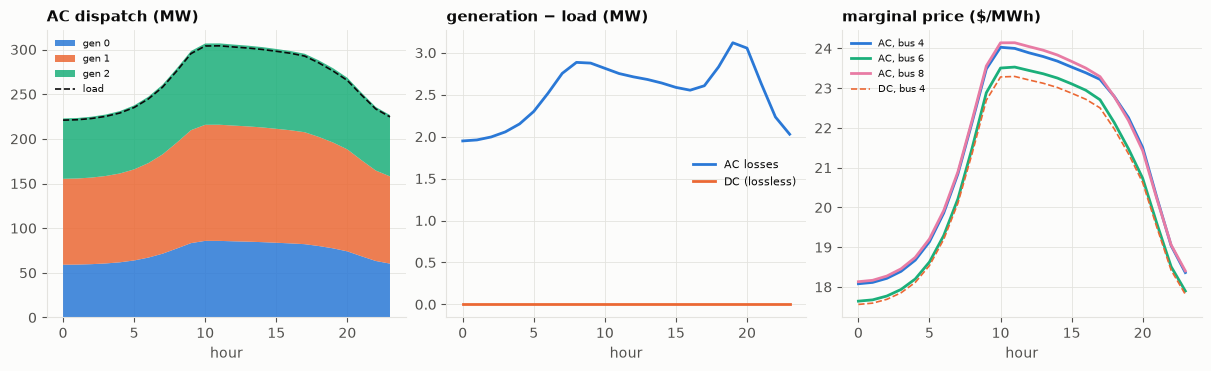

daily cost: AC 100525 $, DC 99244 $ (1.3% lower)


In [7]:
load_mw = BASE_MVA * (PD_NOM * PROFILE).sum(axis=1)
ac_gen = np.array([BASE_MVA * x[2] for x, _ in ac_day])
dc_gen = np.array([BASE_MVA * d[0] for d in dc_day])
ac_lmp = np.array([i["lmp"] for _, i in ac_day])
dc_lmp = np.array([d[1] for d in dc_day])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].stackplot(hours, ac_gen.T, colors=[plotstyle.BLUE, plotstyle.ORANGE, plotstyle.AQUA], labels=[f"gen {g}" for g in GEN_BUS], alpha=0.85)
axes[0].plot(hours, load_mw, color=plotstyle.TEXT, lw=1.2, ls="--", label="load")
axes[0].set_title("AC dispatch (MW)")
axes[0].set_xlabel("hour")
axes[0].legend(fontsize=7, loc="upper left")
axes[1].plot(hours, ac_gen.sum(axis=1) - load_mw, color=plotstyle.BLUE, label="AC losses")
axes[1].plot(hours, dc_gen.sum(axis=1) - load_mw, color=plotstyle.ORANGE, label="DC (lossless)")
axes[1].set_title("generation − load (MW)")
axes[1].set_xlabel("hour")
axes[1].legend(fontsize=8)
for bus, color in ((4, plotstyle.BLUE), (6, plotstyle.AQUA), (8, plotstyle.MAGENTA)):
  axes[2].plot(hours, ac_lmp[:, bus], color=color, label=f"AC, bus {bus}")
axes[2].plot(hours, dc_lmp[:, 4], color=plotstyle.ORANGE, lw=1.2, ls="--", label="DC, bus 4")
axes[2].set_title("marginal price ($/MWh)")
axes[2].set_xlabel("hour")
axes[2].legend(fontsize=7)
plt.show()
ac_cost = np.array([i["cost"] for _, i in ac_day])
dc_cost = np.array([d[2] for d in dc_day])
print(f"daily cost: AC {ac_cost.sum():.0f} $, DC {dc_cost.sum():.0f} $ ({100 * (ac_cost.sum() - dc_cost.sum()) / ac_cost.sum():.1f}% lower)")

### Checking a solution independently

The peak-hour AC solution is checked against the power-flow equations written with the bus
admittance matrix, a formulation independent of the line-flow code above.

In [8]:
def mismatch(theta, v, pg, qg, pd, qd):
  y = np.zeros((N_BUS, N_BUS), dtype=complex)
  for f, t, ys, bc in zip(FROM, TO, Y_SERIES, B_C, strict=True):
    y[f, f] += ys + 0.5j * bc
    y[t, t] += ys + 0.5j * bc
    y[f, t] -= ys
    y[t, f] -= ys
  voltage = v * np.exp(1j * theta)
  gen = np.zeros(N_BUS, dtype=complex)
  gen[GEN_BUS] = pg + 1j * qg
  return np.abs(voltage * np.conj(y @ voltage) - (gen - (pd + 1j * qd))).max()


peak = int(np.argmax(load_mw))
(theta, v, pg, qg), info = ac_day[peak]
print(
  f"hour {peak}: load {load_mw[peak]:.1f} MW, mismatch {mismatch(theta, v, pg, qg, PD_NOM * PROFILE[peak], QD_NOM * PROFILE[peak]):.1e} p.u., voltages {v.min():.3f} to {v.max():.3f} p.u."
)

hour 11: load 304.1 MW, mismatch 1.6e-14 p.u., voltages 1.073 to 1.100 p.u.


## The generated C

Both solvers are C modules with the loads as their only parameter. The AC one links against
IPOPT, the DC one against PIQP.

In [9]:
for solver in (solve_ac, solve_dc):
  module = write_module(solver, GENERATED)
  print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB")

ac_opf_case9.c: 1533 lines, 91 kB
dc_opf_case9.c: 268 lines, 12 kB
